In [1]:
import sys
sys.path.append("/home/landelle/pytorch-cifar/models")
#import util
import resnet
import numpy as np
import torch
import torchvision

import nmixup

In [2]:

transform = torchvision.transforms.transforms.Compose([
    torchvision.transforms.transforms.ToTensor()
])

trainset = torchvision.datasets.CIFAR10(root='/data/landelle/datasets', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='/data/landelle/datasets', train=False, download=True, transform=transform)

trainset, testset

Files already downloaded and verified
Files already downloaded and verified


(Dataset CIFAR10
     Number of datapoints: 50000
     Root location: /data/landelle/datasets
     Split: Train
     StandardTransform
 Transform: Compose(
                ToTensor()
            ), Dataset CIFAR10
     Number of datapoints: 10000
     Root location: /data/landelle/datasets
     Split: Test
     StandardTransform
 Transform: Compose(
                ToTensor()
            ))

In [3]:

BATCH_SIZE = 100
N_BATCHES_IN_TRAIN_SET = len(trainset) // BATCH_SIZE
N_BATCHES_IN_TEST_SET = len(testset) // BATCH_SIZE

NUM_WORKERS = 8

# Fixed learning rate
LR = 0.05 #0.005 LR=0.1 is used by kuangliu with his implementation of ResNet18 for epochs [0;150)

# CIFAR10 number of classes
NUM_CLASS = 10

# CIFAR10 image metadata
CHANNEL, IMAGE_SIZE, _ = trainset[0][0].shape
print("images are:", IMAGE_SIZE, CHANNEL)


images are: 32 3


In [4]:

trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)


In [33]:


"""TRY 1
LAMBDAS = np.zeros((7, 3))#7->6
LAMBDAS[0] = np.array((1, 0, 0))
for i in range(1, 6):
    decr = 6-i#2
    lam_try = np.array((1, 1/decr, 1/(decr*decr))) * .5
    lam_try_normalized = lam_try / lam_try.sum()
    LAMBDAS[i] = lam_try_normalized
"""
def lambdas_loglike(n_cuts, n_vecs):
    lambdas = np.zeros((n_vecs, n_cuts))
    #LAMBDAS[0] = np.array((1, 0, 0, 0))
    for i in range(n_vecs):
        decr = n_vecs - i
        lam_try = np.array([1/(decr**j) for j in range(n_cuts)])
        lam_try_normalized = lam_try / lam_try.sum()
        lambdas[i] = lam_try_normalized
    return lambdas

def lambdas_lininterp(n_cuts, n_vecs):
    """
    Returns n_vecs arrays of n_cuts linearly interpolated lambdas
    The first array is y=1/n_cuts and the last on y=-x
    n_cuts: dimensionality of lamdda arrays (N)
    n_vecs: number of returned arrays
    """
    assert n_vecs >= 2
    assert n_cuts >= 2
    xs = [0., 1.]
    #ys = [1., 0.]
    y_steps = np.arange(n_vecs) * (1./(n_vecs-1))
    ys0 = np.interp(y_steps, [0., 1.], [1./n_cuts, 1.])
    ys1 = np.interp(y_steps, [0., 1.], [0., 1./n_cuts])
    ys1 = np.flip(ys1)    
    steps = np.arange(n_cuts) * (1./(n_cuts-1))
    lambdas = [
        np.interp(steps, xs, [ys0[i], ys1[i]])
        for i in range(n_vecs)]
    lambdas = [l / l.sum() for l in lambdas]
    return lambdas


LAMBDAS: [[8.00000082e-01 1.60000016e-01 3.20000033e-02 6.40000066e-03
  1.28000013e-03 2.56000026e-04 5.12000052e-05 1.02400010e-05
  2.04800021e-06 4.09600042e-07]
 [7.50000715e-01 1.87500179e-01 4.68750447e-02 1.17187612e-02
  2.92969029e-03 7.32422573e-04 1.83105643e-04 4.57764108e-05
  1.14441027e-05 2.86102568e-06]
 [6.66677957e-01 2.22225986e-01 7.40753285e-02 2.46917762e-02
  8.23059206e-03 2.74353069e-03 9.14510229e-04 3.04836743e-04
  1.01612248e-04 3.38707492e-05]
 [5.00488759e-01 2.50244379e-01 1.25122190e-01 6.25610948e-02
  3.12805474e-02 1.56402737e-02 7.82013685e-03 3.91006843e-03
  1.95503421e-03 9.77517107e-04]
 [1.00000000e-01 1.00000000e-01 1.00000000e-01 1.00000000e-01
  1.00000000e-01 1.00000000e-01 1.00000000e-01 1.00000000e-01
  1.00000000e-01 1.00000000e-01]]
[0.         0.11111111 0.22222222 0.33333333 0.44444444 0.55555556
 0.66666667 0.77777778 0.88888889 1.        ] [8.00000082e-01 1.60000016e-01 3.20000033e-02 6.40000066e-03
 1.28000013e-03 2.56000026e-04 

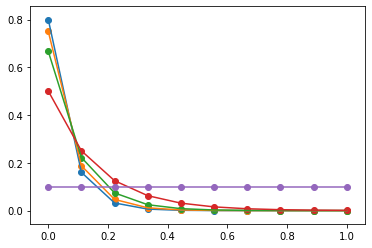

In [34]:
import matplotlib.pyplot as plt

N = 10
N_VECS = 5

LAMBDAS = lambdas_loglike(N, N_VECS)
print("LAMBDAS:", LAMBDAS)
for l in LAMBDAS:
    xs = np.arange(N) / (N-1)
    print(xs, l)
    plt.scatter(xs, l)
    plt.plot(xs, l)
plt.show()


In [35]:

RESULTS_FNAME = "results_n10"
SAVE_RAW = True
if SAVE_RAW:
    with open("results/"+RESULTS_FNAME, "w") as f: pass
    
    
test_accs = nmixup.collect_results_nmix(trainloader, testloader, LAMBDAS, model_getter=nmixup.resnet18,
                                  n_epochs=100, n_batches=None, results_fname=RESULTS_FNAME,
                                  save_raw=SAVE_RAW, use_cuda=True, N_BATCHES_IN_TRAIN_SET=N_BATCHES_IN_TRAIN_SET)
test_accs

Trying lambda= [8.00000082e-01 1.60000016e-01 3.20000033e-02 6.40000066e-03
 1.28000013e-03 2.56000026e-04 5.12000052e-05 1.02400010e-05
 2.04800021e-06 4.09600042e-07]
Performing n-mixup with N-mix: 10
Epoch[1/100]
Loss :2.4161 Epoch[1/100] Batch[0/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :2.1801 Epoch[1/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :2.0419 Epoch[1/100] Batch[100/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :2.0509 Epoch[1/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.9300 Epoch[1/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.8491 Epoch[1/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.9682 Epoch[1/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.8616 Epoch[1/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.9144 Epoch[1/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.8275 Epoch[1/100] Batch[450/500] batch_sh

Loss :1.0162 Epoch[10/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0494 Epoch[10/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0199 Epoch[10/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32, 32])
Epoch[11/100]
Loss :0.9608 Epoch[11/100] Batch[0/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9074 Epoch[11/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9546 Epoch[11/100] Batch[100/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9266 Epoch[11/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9650 Epoch[11/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9749 Epoch[11/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9342 Epoch[11/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0403 Epoch[11/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0328 Epoch[11/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32

Loss :0.9154 Epoch[20/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.8676 Epoch[20/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.8810 Epoch[20/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9367 Epoch[20/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.8990 Epoch[20/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32, 32])
Epoch[21/100]
Loss :0.8628 Epoch[21/100] Batch[0/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9062 Epoch[21/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9589 Epoch[21/100] Batch[100/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.8811 Epoch[21/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.8705 Epoch[21/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.8978 Epoch[21/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9373 Epoch[21/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32

Loss :0.9046 Epoch[30/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.8887 Epoch[30/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.8647 Epoch[30/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.8978 Epoch[30/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.8727 Epoch[30/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.8766 Epoch[30/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.8867 Epoch[30/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32, 32])
Epoch[31/100]
Loss :0.8786 Epoch[31/100] Batch[0/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.8795 Epoch[31/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.8807 Epoch[31/100] Batch[100/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.8671 Epoch[31/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9072 Epoch[31/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32

Loss :0.8831 Epoch[40/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.8711 Epoch[40/100] Batch[100/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.8737 Epoch[40/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.8695 Epoch[40/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.8780 Epoch[40/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.8656 Epoch[40/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.8643 Epoch[40/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.8610 Epoch[40/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.8784 Epoch[40/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32, 32])
Epoch[41/100]
Loss :0.8719 Epoch[41/100] Batch[0/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.8523 Epoch[41/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.8617 Epoch[41/100] Batch[100/500] batch_shape:torch.Size([100, 3, 32,

...

Loss :0.9717 Epoch[67/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9720 Epoch[67/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9912 Epoch[67/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9384 Epoch[67/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9705 Epoch[67/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9782 Epoch[67/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9792 Epoch[67/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32, 32])
Epoch[68/100]
Loss :0.9778 Epoch[68/100] Batch[0/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0164 Epoch[68/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9522 Epoch[68/100] Batch[100/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9780 Epoch[68/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9545 Epoch[68/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32

Loss :0.9780 Epoch[77/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9710 Epoch[77/100] Batch[100/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9927 Epoch[77/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9427 Epoch[77/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9585 Epoch[77/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9559 Epoch[77/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0075 Epoch[77/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0016 Epoch[77/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9856 Epoch[77/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32, 32])
Epoch[78/100]
Loss :0.9563 Epoch[78/100] Batch[0/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0250 Epoch[78/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9627 Epoch[78/100] Batch[100/500] batch_shape:torch.Size([100, 3, 32,

Loss :0.9732 Epoch[86/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32, 32])
Epoch[87/100]
Loss :0.9903 Epoch[87/100] Batch[0/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9634 Epoch[87/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9681 Epoch[87/100] Batch[100/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0035 Epoch[87/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9689 Epoch[87/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9976 Epoch[87/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9653 Epoch[87/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9567 Epoch[87/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9630 Epoch[87/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9753 Epoch[87/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32, 32])
Epoch[88/100]
Loss :0.9223 Epoch[88/100] Batch[0/500] batch_shape:torch.Size

Loss :0.9686 Epoch[96/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9330 Epoch[96/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9454 Epoch[96/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32, 32])
Epoch[97/100]
Loss :1.0068 Epoch[97/100] Batch[0/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9301 Epoch[97/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9472 Epoch[97/100] Batch[100/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9551 Epoch[97/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9577 Epoch[97/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9446 Epoch[97/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9592 Epoch[97/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9668 Epoch[97/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9762 Epoch[97/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32

AssertionError: 

In [9]:
test_accs

{'[0.53333333 0.26666667 0.13333333 0.06666667]': 83.88,
 '[0.25 0.25 0.25 0.25]': 69.1}

In [8]:
import pandas as pd

test_accs_df = pd.DataFrame(test_accs2, index=["Test acc"]).T

NameError: name 'test_accs2' is not defined

In [ ]:
ax = test_accs_df.plot.bar(rot=20)
ax.set_ylim(80,90)